In [197]:
import matplotlib.pyplot as plt
import graphviz.backend as he
import pandas as pd

from sklearn import tree
from dtreeviz import model
from dtreeviz.trees import *
from sklearn.datasets import *
from sklearn.tree import plot_tree
from sklearn.datasets import load_iris
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import fetch_openml
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from dtreeviz.trees import explain_prediction_plain_english

In [198]:
clas = tree.DecisionTreeClassifier()
iris = load_iris()

X_train = iris.data
y_train = iris.target
clas.fit(X_train, y_train)

DecisionTreeClassifier()

[Text(0.5, 0.9166666666666666, 'x[3] <= 0.8\ngini = 0.667\nsamples = 150\nvalue = [50, 50, 50]'),
 Text(0.4230769230769231, 0.75, 'gini = 0.0\nsamples = 50\nvalue = [50, 0, 0]'),
 Text(0.46153846153846156, 0.8333333333333333, 'True  '),
 Text(0.5769230769230769, 0.75, 'x[3] <= 1.75\ngini = 0.5\nsamples = 100\nvalue = [0, 50, 50]'),
 Text(0.5384615384615384, 0.8333333333333333, '  False'),
 Text(0.3076923076923077, 0.5833333333333334, 'x[2] <= 4.95\ngini = 0.168\nsamples = 54\nvalue = [0, 49, 5]'),
 Text(0.15384615384615385, 0.4166666666666667, 'x[3] <= 1.65\ngini = 0.041\nsamples = 48\nvalue = [0, 47, 1]'),
 Text(0.07692307692307693, 0.25, 'gini = 0.0\nsamples = 47\nvalue = [0, 47, 0]'),
 Text(0.23076923076923078, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.46153846153846156, 0.4166666666666667, 'x[3] <= 1.55\ngini = 0.444\nsamples = 6\nvalue = [0, 2, 4]'),
 Text(0.38461538461538464, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [0, 0, 3]'),
 Text(0.5384615384615384, 0.25, '

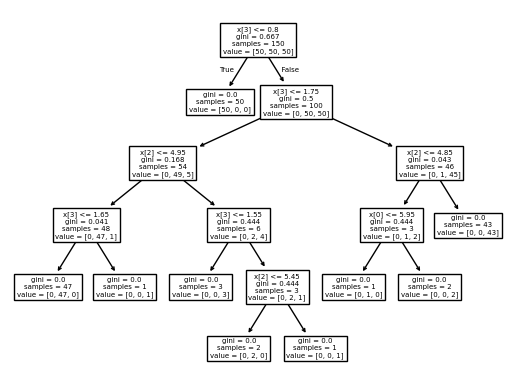

In [199]:
plot_tree(clas)

#### 1. Classification

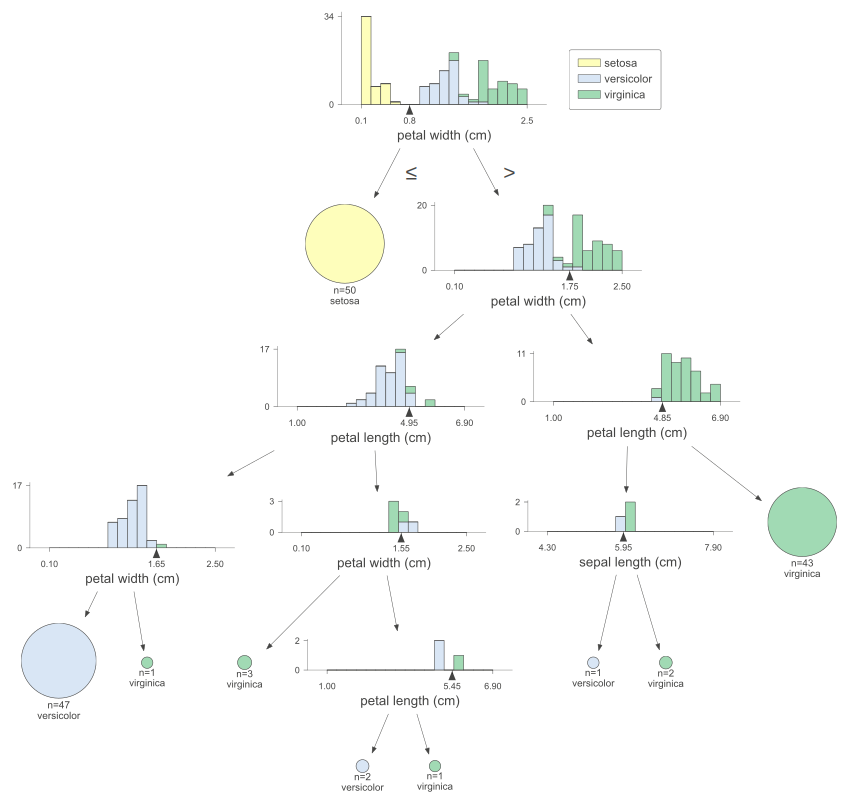

In [200]:
viz = model(
    clas,
    X_train,
    y_train,
    feature_names = iris.feature_names,
    class_names = ["setosa", "versicolor", "virginica"]
)

viz.view(scale = 1.5)

#### 2. Regression

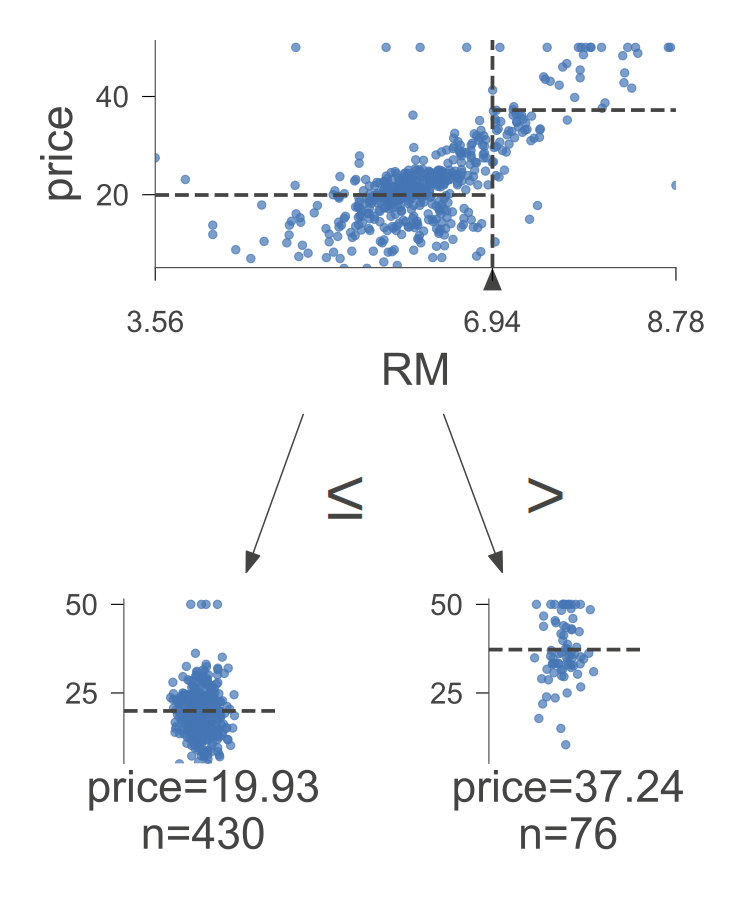

In [201]:
regr = tree.DecisionTreeRegressor(max_depth=1)
boston = fetch_openml(name="boston", version=1, as_frame=False)

X_train = boston.data
y_train = boston.target

regr.fit(X_train, y_train)

viz = model(
    regr,
    X_train,
    y_train,
    target_name = 'price',
    feature_names = boston.feature_names
)

viz.view(scale = 5)

#### 3. Horizontal Decision Tree

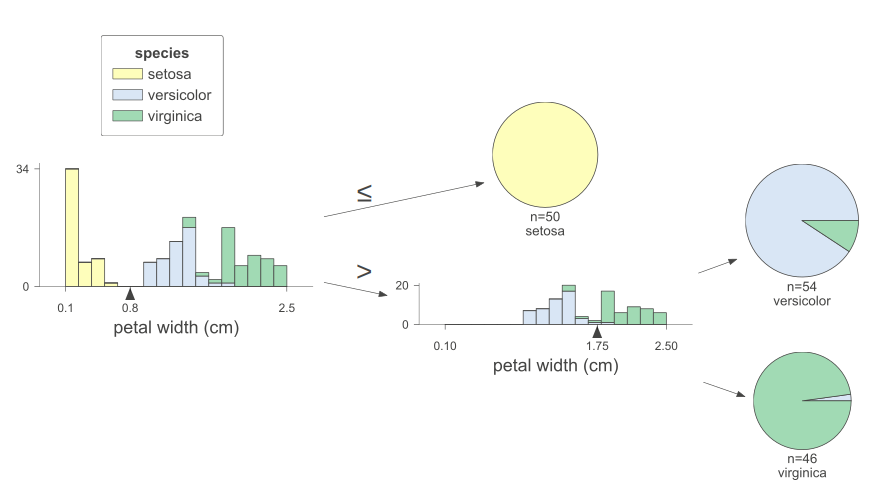

In [202]:
iris = load_iris()

X_train = iris.data
y_train = iris.target

clas = DecisionTreeClassifier(max_depth=2)
clas.fit(X_train, y_train)

viz = model(
    clas,
    X_train,
    y_train,
    target_name='species',
    feature_names=iris.feature_names,
    class_names=["setosa", "versicolor", "virginica"]
)

viz.view(scale=2, orientation="LR")

#### 4. Show Prediction Path

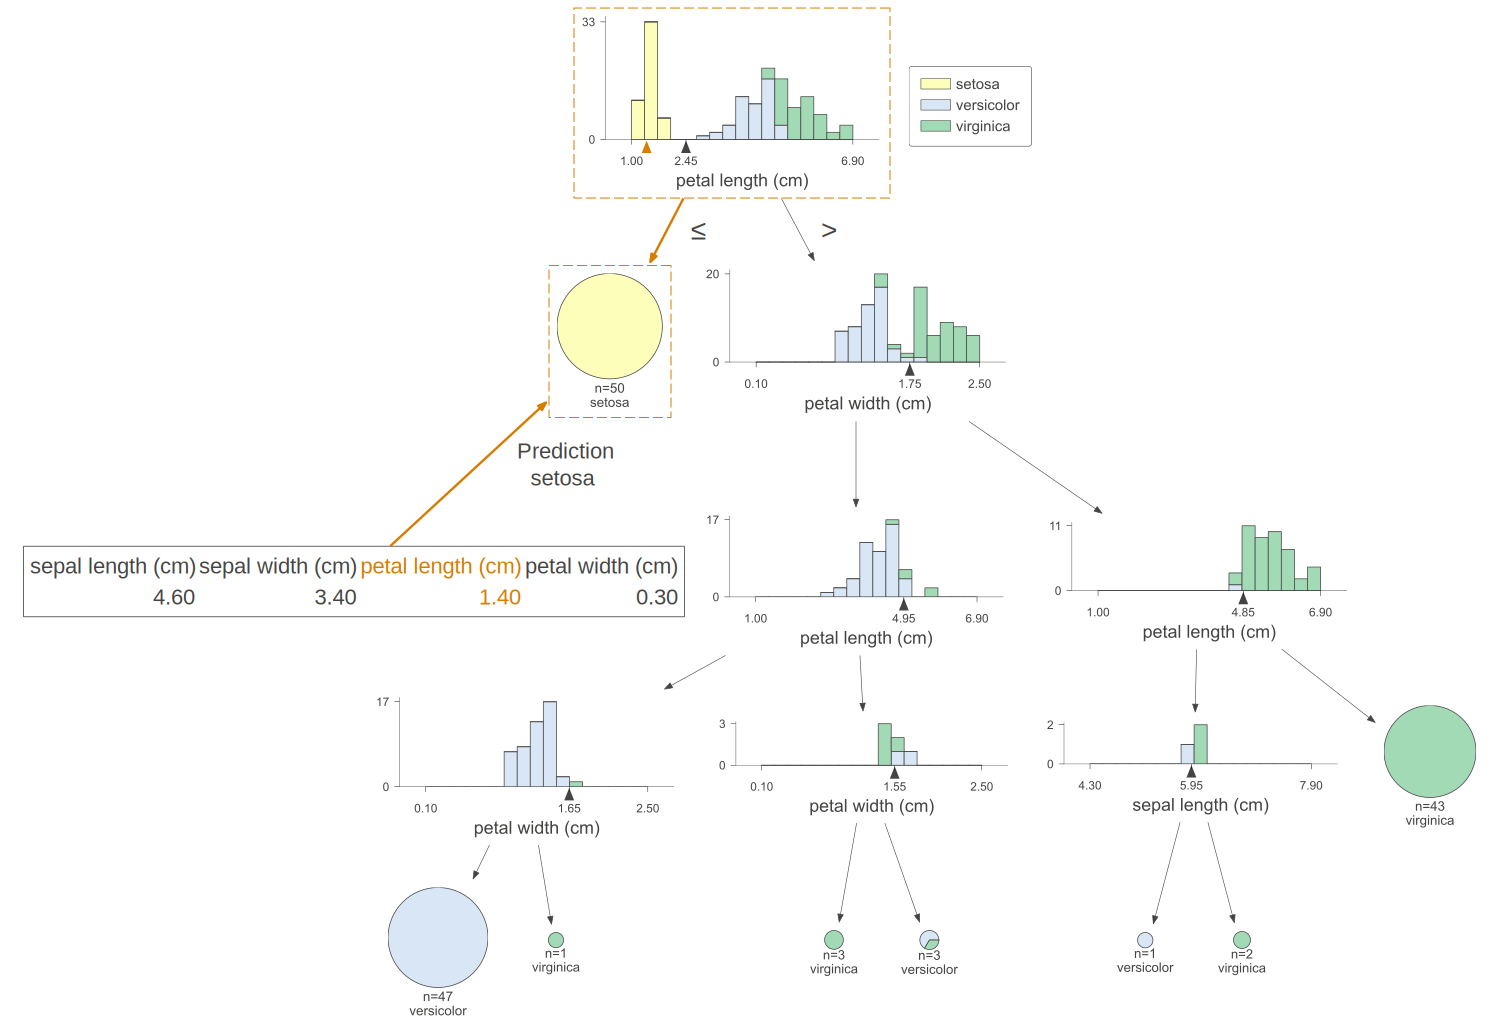

In [203]:
iris = load_iris()

X_train = iris.data
y_train = iris.target

clas = DecisionTreeClassifier(max_depth=4)
clas.fit(X_train, y_train)

X = iris.data[np.random.randint(0, len(iris.data)), :]

viz = model(
    clas,
    X_train,
    y_train,
    feature_names=iris.feature_names,
    class_names=["setosa", "versicolor", "virginica"]
)

viz.view(scale=2, x = X)

In [204]:
X

array([4.6, 3.4, 1.4, 0.3])

#### 5. Show Node Number

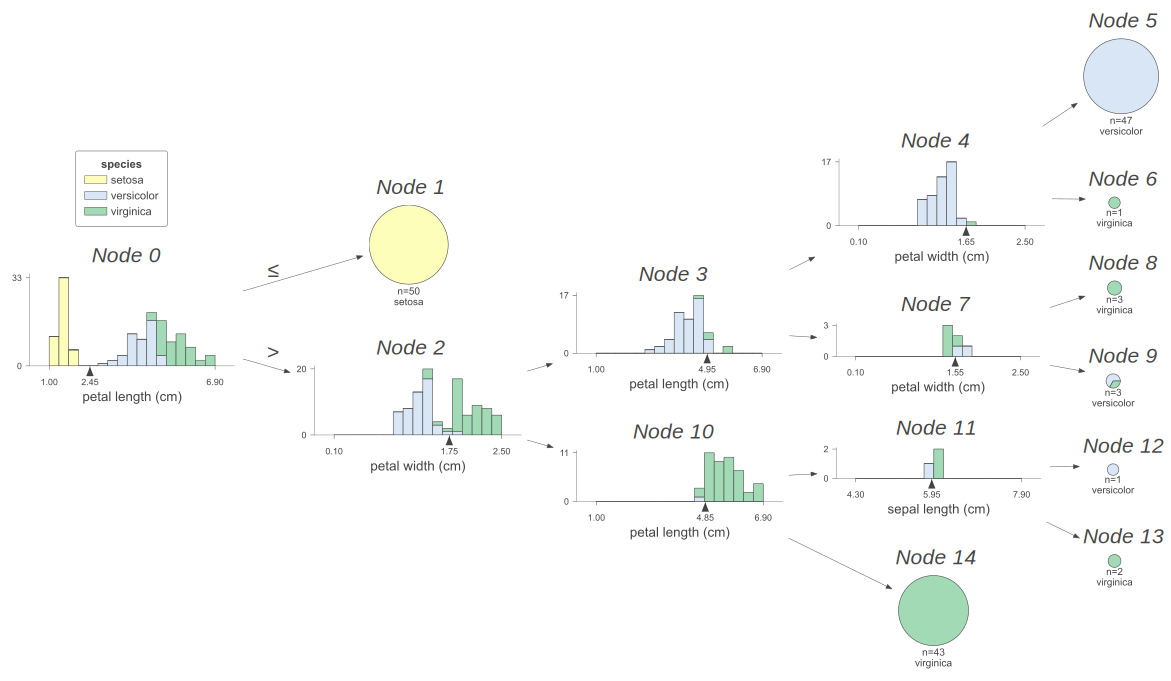

In [205]:
viz = model(
    clas,
    X_train,
    y_train,
    target_name='species',
    feature_names=iris.feature_names,
    class_names=["setosa", "versicolor", "virginica"]
)

viz.view(scale=1.5, histtype='barstacked', orientation='LR', show_node_labels=True)

#### 6. Without Any Graphs

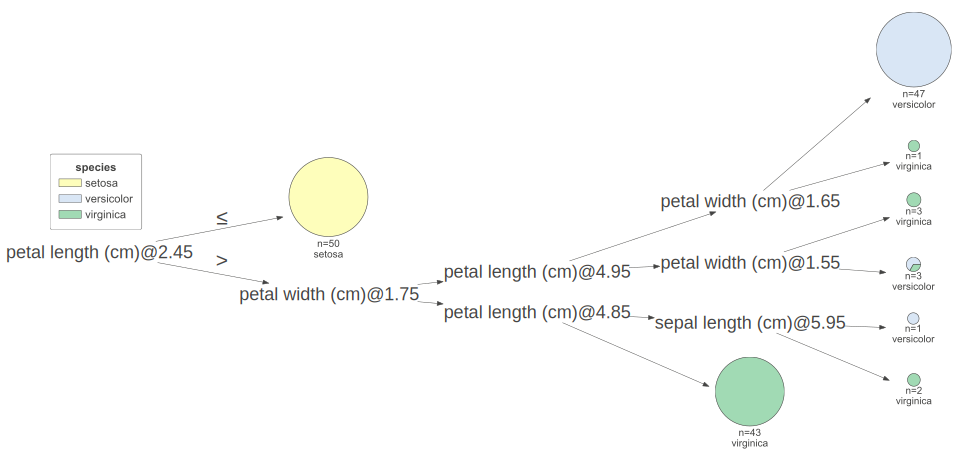

In [206]:
viz = model(
    clas,
    X_train,
    y_train,
    target_name='species',
    feature_names=iris.feature_names,
    class_names=["setosa", "versicolor", "virginica"]
)

viz.view(scale=1.5, histtype='barstacked', orientation='LR', fancy=False)

#### 7. Show Just Predicted Path and Nothing Else

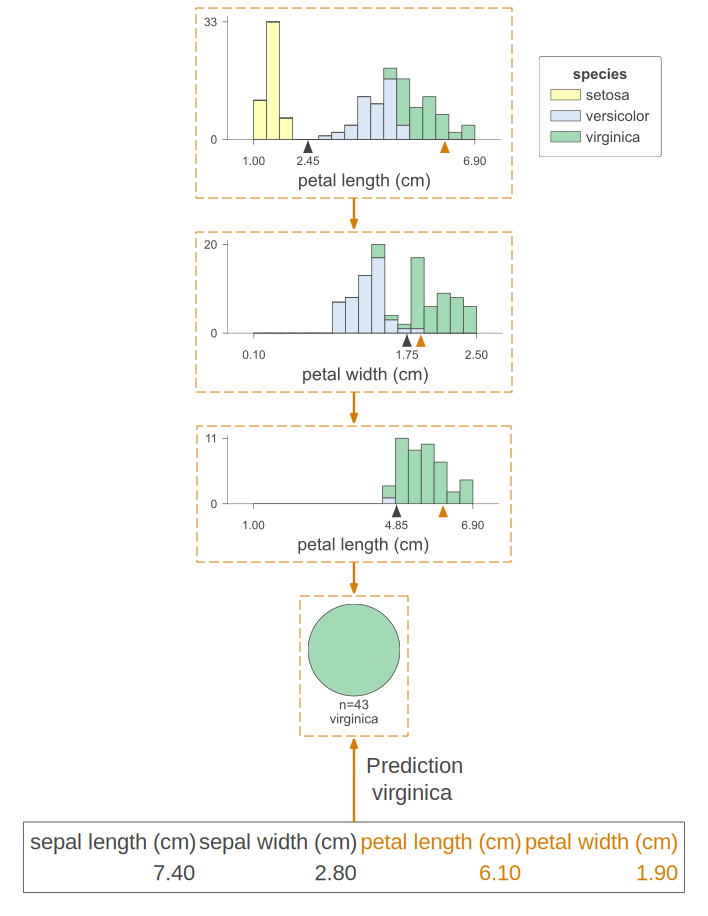

In [207]:
iris = load_iris()

X_train = iris.data
y_train = iris.target

clas = DecisionTreeClassifier(max_depth=4)
clas.fit(X_train, y_train)

X = iris.data[np.random.randint(0, len(iris.data)), :]

viz = model(
    clas,
    X_train,
    y_train,
    target_name='species',
    feature_names=iris.feature_names,
    class_names=["setosa", "versicolor", "virginica"]
)

viz.view(scale=2, x = X, show_just_path=True)

#### 8. Predicted Path in Plain English

In [209]:
print(
    explain_predction_path(clas, X, feature_names=iris.feature_names, explanation_type='plain_english')
)

NameError: name 'explain_predction_path' is not defined

#### 9. Feature Importance

In [210]:
print(
    explain_prediction_path(clas, X, feature_names=iris.feature_names, explanation_type='sklearn_default')
)

NameError: name 'explain_prediction_path' is not defined

#### 10. Univariate Regression

NameError: name 'rtreeviz_univar' is not defined

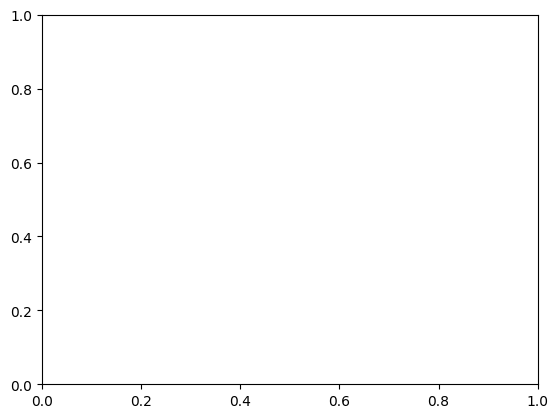

In [211]:
df_cars = pd.read_csv("Dataset/auto-mpg.csv")
X, y = df_cars[['weight']], df_cars['mpg']

dt = DecisionTreeRegressor(max_depth=3, criterion="absolute_error")
dt.fit(X, y)

fig = plt.figure()
ax = fig.gca()
rtreeviz_univar(dt, X, y, 'weight', 'mpg', ax=ax)
plt.show()

#### 11. 3-D Regression

NameError: name 'rtreeviz_bivar_3d' is not defined

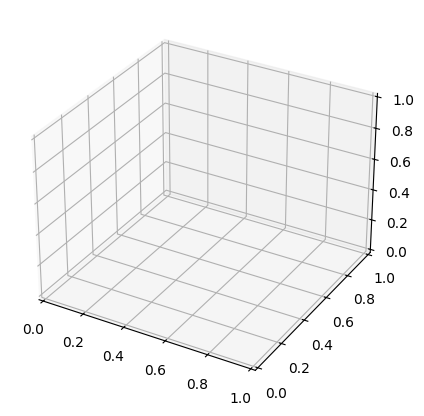

In [212]:
df_cars['horsepower'] = pd.to_numeric(df_cars['horsepower'], errors='coerce')
df_cars['weight'] = pd.to_numeric(df_cars['weight'], errors='coerce')

df_cars = df_cars.dropna(subset=['weight', 'horsepower', 'mpg'])

X = df_cars[['weight', 'horsepower']]
y = df_cars['mpg']

dt = DecisionTreeRegressor(max_depth=3, criterion='absolute_error')
dt.fit(X, y)

figsize = (6,5)
fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(111, projection='3d')

t = rtreeviz_bivar_3d(
    dt,
    X,
    y,
    feature_names = ['Weight', 'Horsepower'],
    target_name = 'MPG',
    fontsize = 14,
    elev = 20,
    azim = 25,
    dist = 8.2,
    show={'splits', 'title'},
    ax=ax
)

plt.show()

C:\Users\ACER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names


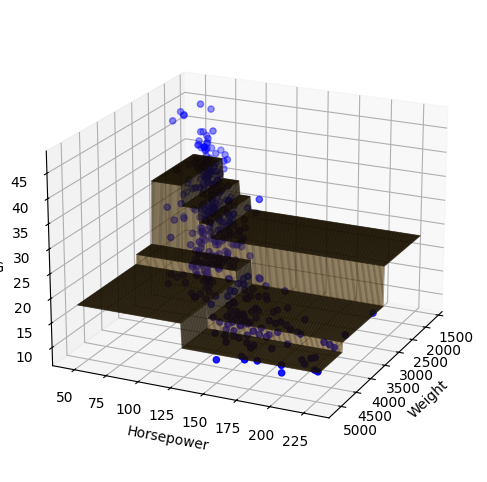

In [214]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Fine grid to show step changes
weight_grid = np.linspace(X['weight'].min(), X['weight'].max(), 200)
hp_grid = np.linspace(X['horsepower'].min(), X['horsepower'].max(), 200)
W, H = np.meshgrid(weight_grid, hp_grid)
grid_points = np.c_[W.ravel(), H.ravel()]

# Predict
Z = dt.predict(grid_points).reshape(W.shape)

# Plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# Plot the tree surface with visible edges
ax.plot_surface(W, H, Z, alpha=0.4, color='orange', edgecolor='k', linewidth=0.5, rstride=1, cstride=1)

# Scatter the original data
ax.scatter(X['weight'], X['horsepower'], y, c='blue', s=20)

ax.set_xlabel('Weight')
ax.set_ylabel('Horsepower')
ax.set_zlabel('MPG')
ax.view_init(elev=20, azim=25)
plt.show()